# Lab 10 — การทดลอง machine learning และการประเมินผล
### Train/val/test, k-fold, confusion matrix, precision/recall/F1, ROC, micro vs macro

**กลุ่ม:** D evaluation · **อ่านคู่กับสไลด์หน้า:** 121-152 · **เวลาโดยประมาณ:** 90 นาที · **Dataset:** churn (สังเคราะห์ 1,000 แถว), breast_cancer (sklearn), digits (sklearn), ตาราง Virus/Bacteria/Fungus จากสไลด์

**ควรทำมาก่อน:** Lab 05 (Perceptron) และ Lab 07 (NeuralNetwork) — เราจะใช้สองโมเดลนี้เป็น "ตัวถูกประเมิน"

## จุดประสงค์การเรียนรู้
เมื่อทำ lab นี้จบ นิสิตจะสามารถ
1. แบ่งข้อมูลแบบ stratified เป็น train/test และ train/val/test ได้ด้วยมือ และอธิบายได้ว่าแต่ละส่วนใช้ทำอะไร
2. ทำ k-fold cross validation และรายงานผลเป็น mean ± std
3. นับ TP / FP / TN / FN สร้าง confusion matrix และคำนวณ accuracy, precision, recall, specificity, F1 จากมันได้
4. เลือก metric ให้เหมาะกับปัญหา และเลือกโมเดลภายใต้ข้อจำกัด (maximize objective subject to constraints)
5. วาด ROC curve จากการกวาด threshold τ และคำนวณ AUC
6. คำนวณ micro average กับ macro average ของ multiclass classification และรู้ว่าต่างกันอย่างไร

> **วิธีใช้ notebook นี้:** อ่าน markdown cell ก่อน แล้วรัน code cell ถัดไปด้วย `Shift+Enter` ทีละ cell ตามลำดับ
> ทุก code cell มีคำอธิบายว่าทำอะไรและทำไม ถ้าอยากทดลอง ให้แก้ตัวเลขใน cell แล้วรันซ้ำได้เลย

## เตรียมเครื่องมือ
cell แรกของทุก lab จะ import library ที่ใช้ และตั้ง **seed** ให้ตัวเลขสุ่มเหมือนกันทุกครั้งที่รัน
(ไม่งั้นค่าเริ่มต้นของ weight จะต่างกันทุกรอบ และตัวเลขในหน้าจอจะไม่ตรงกับคำอธิบาย)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import nnlab                      # package ประกอบ lab (ติดตั้งแล้วด้วย uv sync)
except ImportError:                   # เผื่อเปิดด้วย kernel อื่น: เพิ่ม lab/src เข้า path เอง
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
    import nnlab

from nnlab.utils import set_seed
import pandas as pd
rng = set_seed(463)                   # 463 = เลขวิชา CP463
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline
print("numpy", np.__version__, "| nnlab", nnlab.__version__)

numpy 2.2.6 | nnlab 0.1.0


## สัญลักษณ์ในบทนี้
| สัญลักษณ์ | ความหมาย | ที่มา |
|---|---|---|
| $y$, $\hat{y}$ | label จริง และ label ที่โมเดลทำนาย (0/1 สำหรับ binary) | p.131 |
| **positive class** | class ที่เรา "สนใจจับ" เช่น churn = 1, มีโรค = 1 | p.152 |
| TP, FP, TN, FN | True/False Positive/Negative — นับจำนวน sample ในแต่ละกรณี | p.127-130 |
| $\tau$ | decision threshold: ทำนาย positive เมื่อ $P(y=1\mid x) \ge \tau$ (ค่า default 0.5) | p.140 |
| TPR, FPR | True/False Positive Rate = recall และ $1 -$ specificity ใช้วาด ROC | p.140 |
| $\mathrm{TP}_c$ | TP ของ class $c$ เมื่อมองแบบ one-vs-rest (class $c$ = positive ที่เหลือ = negative) | p.144 |

## ขั้นที่ 1 · ML experiment: แบ่งข้อมูลก่อนเทรน (สไลด์ p.122-125)
คำถามแรกของทุกการทดลอง: **จะรู้ได้อย่างไรว่าโมเดลใช้ได้กับข้อมูลที่ยังไม่เคยเห็น?**
ถ้าเราวัดผลบนข้อมูลชุดเดียวกับที่ใช้เทรน โมเดลที่ "จำ" ข้อมูลได้ทั้งหมดจะได้คะแนนเต็มโดยไม่ได้เรียนอะไรเลย
สไลด์ p.122 จึงแบ่งข้อมูล $(X, y)$ เป็น **training set** กับ **test set** ในสัดส่วน 80:20 หรือ 70:30
โดยใช้ **stratified sampling** คือแบ่งแยกกันภายในแต่ละ class เพื่อให้สัดส่วน yes:no ของทั้งสองชุดเท่ากับข้อมูลเดิม

เราจะใช้ churn dataset (ลูกค้า 1,000 คน churn ≈ 31%) แบ่งด้วยมือก่อน แล้วค่อยเทียบกับ `train_test_split` ของ scikit-learn

> **Convention ที่ใช้ในส่วนนี้: library (pandas / scikit-learn / PyTorch)** — `X` มี shape `(m, n_x)` sample เป็น**แถว**, `y` มี shape `(m,)` และ `Z = X @ W.T + b`

cell นี้แบ่ง 80:20 ด้วยมือทีละ class: สุ่มสลับ index ของ class นั้น ตัด 20% แรกเป็น test ที่เหลือเป็น train
สังเกตว่าสัดส่วน churn ของ train และ test ต้องออกมา ≈ 0.31 เท่าข้อมูลเดิม
เทียบกับการสุ่มแบบไม่ stratify (สุ่มทั้งก้อน) ที่สัดส่วนจะคลาดเคลื่อนไปบ้าง — ถ้า dataset เล็กหรือ class เล็กมาก ความคลาดเคลื่อนนี้ทำให้ผลประเมินเชื่อไม่ได้

In [2]:
from nnlab.data import load_churn_synthetic

X_all, y_all, feature_names = load_churn_synthetic()      # X_all: (m, n_x) = (1000, 6), y_all: (m,)
print("X_all", X_all.shape, "| y_all", y_all.shape, "| features:", feature_names)
print("จำนวนแต่ละ class (0 = stay, 1 = churn):", np.bincount(y_all), "| สัดส่วน churn = %.3f" % y_all.mean())

test_ratio = 0.2
train_idx, test_idx = [], []
for c in np.unique(y_all):                                # แบ่งทีละ class → stratified
    idx = np.flatnonzero(y_all == c)                      # index ของ sample ที่เป็น class c
    rng.shuffle(idx)
    n_test = int(round(len(idx) * test_ratio))
    test_idx.extend(idx[:n_test])
    train_idx.extend(idx[n_test:])
train_idx, test_idx = np.array(train_idx), np.array(test_idx)

X_train, y_train = X_all[train_idx], y_all[train_idx]     # X_train: (800, 6)
X_test,  y_test  = X_all[test_idx],  y_all[test_idx]      # X_test : (200, 6)
print(f"\nstratified 80:20 → train {len(y_train)} | test {len(y_test)}")
print(f"สัดส่วน churn: train {y_train.mean():.3f} | test {y_test.mean():.3f}   ← เท่าข้อมูลเดิม")

# เทียบ: สุ่มทั้งก้อนโดยไม่ดู class
perm = rng.permutation(len(y_all))
y_te_random = y_all[perm[:200]]
print(f"ถ้าสุ่มทั้งก้อน (ไม่ stratify): test churn = {y_te_random.mean():.3f}   ← คลาดจากสัดส่วนเดิม {y_all.mean():.3f}")

X_all (1000, 6) | y_all (1000,) | features: ['monthly_usage_hours', 'tenure_months', 'support_tickets', 'subscription_type_Basic', 'subscription_type_Premium', 'subscription_type_Standard']
จำนวนแต่ละ class (0 = stay, 1 = churn): [689 311] | สัดส่วน churn = 0.311

stratified 80:20 → train 800 | test 200
สัดส่วน churn: train 0.311 | test 0.310   ← เท่าข้อมูลเดิม
ถ้าสุ่มทั้งก้อน (ไม่ stratify): test churn = 0.260   ← คลาดจากสัดส่วนเดิม 0.311


scikit-learn ทำสิ่งเดียวกันด้วย `train_test_split(..., stratify=y)` และ `nnlab.data.stratified_split` ก็คือ loop ด้านบนที่จัดเป็นฟังก์ชัน
สัดส่วนต้องตรงกัน (sample ที่ถูกเลือกต่างกันได้ เพราะลำดับสุ่มต่างกัน)

In [3]:
from sklearn.model_selection import train_test_split
from nnlab.data import stratified_split

Xtr_sk, Xte_sk, ytr_sk, yte_sk = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=463)
Xtr_nn, Xte_nn, ytr_nn, yte_nn = stratified_split(X_all, y_all, test_ratio=0.2, seed=463)

print(f"sklearn : train {Xtr_sk.shape} churn {ytr_sk.mean():.3f} | test {Xte_sk.shape} churn {yte_sk.mean():.3f}")
print(f"nnlab   : train {Xtr_nn.shape} churn {ytr_nn.mean():.3f} | test {Xte_nn.shape} churn {yte_nn.mean():.3f}")
assert np.bincount(yte_sk).tolist() == np.bincount(yte_nn).tolist() == np.bincount(y_test).tolist()
print("จำนวนแต่ละ class ใน test เท่ากันทั้ง 3 วิธี:", np.bincount(y_test))

sklearn : train (800, 6) churn 0.311 | test (200, 6) churn 0.310
nnlab   : train (800, 6) churn 0.311 | test (200, 6) churn 0.310
จำนวนแต่ละ class ใน test เท่ากันทั้ง 3 วิธี: [138  62]


### train / validation / test (สไลด์ p.123)
test set ใช้ได้ **ครั้งเดียว** ตอนจบ — ถ้าเราลองปรับ hyperparameter (learning rate, จำนวน epoch, ขนาด hidden layer) แล้วดูคะแนนบน test ซ้ำๆ
test ก็จะกลายเป็นข้อมูลที่เรา "เห็น" ไปแล้ว สไลด์ p.123 จึงแบ่งชุดที่สามคือ **validation set** ไว้สำหรับปรับ hyperparameter และตัดสินว่าจะ "Stop Learning" เมื่อไร
วิธีทำง่ายที่สุด: แบ่ง train ที่ได้จากขั้นก่อนออกอีกครั้ง 75:25 → รวมแล้วเป็น 60:20:20

In [4]:
X_tr2, X_val, y_tr2, y_val = stratified_split(X_train, y_train, test_ratio=0.25, seed=463)   # 800 → 600 : 200
print(f"train {X_tr2.shape[0]} | val {X_val.shape[0]} | test {X_test.shape[0]}   (= 60 : 20 : 20 ของ 1,000)")
print(f"สัดส่วน churn: train {y_tr2.mean():.3f} | val {y_val.mean():.3f} | test {y_test.mean():.3f}")
print("\nหน้าที่: train → เรียน θ | val → เลือก hyperparameter / หยุดเทรน | test → รายงานผลครั้งเดียวตอนจบ")

train 600 | val 200 | test 200   (= 60 : 20 : 20 ของ 1,000)
สัดส่วน churn: train 0.312 | val 0.310 | test 0.310

หน้าที่: train → เรียน θ | val → เลือก hyperparameter / หยุดเทรน | test → รายงานผลครั้งเดียวตอนจบ


### k-fold cross validation (สไลด์ p.124-125)
เมื่อข้อมูลมีน้อย การกันไว้ 20% เป็น validation ทำให้เหลือข้อมูลเทรนน้อยลง และคะแนน validation ก็ขึ้นกับว่า "สุ่มได้ชุดไหน"
k-fold แก้ปัญหานี้: แบ่ง training set เป็น k ก้อน (fold) แล้วทำการทดลอง k ครั้ง — ครั้งที่ i ใช้ fold i เป็น validation ที่เหลือเป็น train
ทุก sample จึงถูกใช้เป็น validation **ครั้งเดียวพอดี** และเราได้คะแนน k ค่าที่เอามาหา mean ± std

cell นี้วาดตารางแบบสไลด์ p.125 บนข้อมูลจำลอง 20 sample (12 ตัว class 0, 8 ตัว class 1) ด้วย `nnlab.data.kfold_indices`
ในตาราง 1 = sample นั้นเป็น validation ของการทดลองแถวนั้น, 0 = อยู่ใน train — แต่ละคอลัมน์ต้องรวมได้ 1

In [5]:
from nnlab.data import kfold_indices

y_small = np.array([0] * 12 + [1] * 8)                    # (20,)
folds = kfold_indices(y_small, k=5, seed=463)             # list ของ (train_idx, val_idx) 5 คู่

table = np.zeros((5, len(y_small)), dtype=int)            # table: (k, m)
for i, (tr, va) in enumerate(folds):
    table[i, va] = 1
    print(f"exp {i+1}: val = {va.tolist()}  (class 1 ใน val: {y_small[va].sum()} ตัว) | train {len(tr)} ตัว")

df_folds = pd.DataFrame(table, index=[f"exp {i+1}" for i in range(5)], columns=[f"s{j}" for j in range(len(y_small))])
display(df_folds)
assert (table.sum(axis=0) == 1).all(), "ทุก sample ต้องเป็น validation ครั้งเดียว"
print("ผลรวมแต่ละคอลัมน์ =", np.unique(table.sum(axis=0)), "→ ทุก sample ถูก validate 1 ครั้งพอดี")

exp 1: val = [0, 1, 7, 12, 14]  (class 1 ใน val: 2 ตัว) | train 15 ตัว
exp 2: val = [2, 6, 10, 17, 18]  (class 1 ใน val: 2 ตัว) | train 15 ตัว
exp 3: val = [3, 4, 16, 19]  (class 1 ใน val: 2 ตัว) | train 16 ตัว
exp 4: val = [9, 11, 15]  (class 1 ใน val: 1 ตัว) | train 17 ตัว
exp 5: val = [5, 8, 13]  (class 1 ใน val: 1 ตัว) | train 17 ตัว


,s0,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19
exp 1,1,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0
exp 2,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,0
exp 3,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
exp 4,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0
exp 5,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0


ผลรวมแต่ละคอลัมน์ = [1] → ทุก sample ถูก validate 1 ครั้งพอดี


ตอนนี้ทำจริงกับ churn: ใช้ `nnlab.data.get_dataset("churn")` ซึ่งแบ่ง 80:20 และ normalize feature ให้แล้ว
แล้วรัน 5-fold CV ของ `Perceptron` (lab05) บน training set รายงาน accuracy ของแต่ละ fold และ mean ± std
ค่า std บอกว่าคะแนน "แกว่ง" แค่ไหนตามชุดข้อมูล — ถ้าเทียบสองโมเดลแล้ว mean ต่างกันน้อยกว่า std ก็ยังสรุปไม่ได้ว่าใครดีกว่า
สุดท้ายค่อยเทรนด้วย train ทั้งหมดแล้ววัดบน test **ครั้งเดียว**

In [6]:
from nnlab.data import get_dataset
from nnlab.perceptron import Perceptron

X_tr, X_te, y_tr, y_te, n_classes = get_dataset("churn")  # X_tr: (800, 6) normalize แล้ว | X_te: (200, 6)
print("train", X_tr.shape, "| test", X_te.shape, "| classes", n_classes)

fold_acc = []
for i, (tr, va) in enumerate(kfold_indices(y_tr, k=5, seed=463)):
    model = Perceptron(lr=0.1, epochs=500).fit(X_tr[tr], y_tr[tr])
    acc = model.evaluate(X_tr[va], y_tr[va])["accuracy"]
    fold_acc.append(acc)
    print(f"fold {i+1}: train {len(tr)} | val {len(va)} | val accuracy = {acc:.4f}")
fold_acc = np.array(fold_acc)                             # (5,)
print(f"\n5-fold CV accuracy = {fold_acc.mean():.4f} ± {fold_acc.std():.4f}")

final = Perceptron(lr=0.1, epochs=500).fit(X_tr, y_tr)    # เทรนด้วย train ทั้งหมด
print(f"test accuracy (วัดครั้งเดียว) = {final.evaluate(X_te, y_te)['accuracy']:.4f}")
print("baseline ทายว่า 'stay' ทุกคน =", f"{1 - y_te.mean():.4f}", "← accuracy อย่างเดียวบอกไม่หมด → ขั้นที่ 2")

train (800, 6) | test (200, 6) | classes 2
fold 1: train 639 | val 161 | val accuracy = 0.7329
fold 2: train 640 | val 160 | val accuracy = 0.7562
fold 3: train 640 | val 160 | val accuracy = 0.7000
fold 4: train 640 | val 160 | val accuracy = 0.7375
fold 5: train 641 | val 159 | val accuracy = 0.7107

5-fold CV accuracy = 0.7275 ± 0.0200
test accuracy (วัดครั้งเดียว) = 0.7400
baseline ทายว่า 'stay' ทุกคน = 0.6900 ← accuracy อย่างเดียวบอกไม่หมด → ขั้นที่ 2


## ขั้นที่ 2 · ความผิดพลาด 4 แบบและ confusion matrix (สไลด์ p.127-131)
accuracy ≈ 0.73 (CV) และ 0.74 (test) ดูดี แต่ถ้าทายว่า "ไม่ churn" ทุกคนก็ได้ 0.69 แล้ว — ปัญหาคือ accuracy ไม่บอกว่าโมเดล**พลาดแบบไหน**
ใน binary classification เรากำหนด **positive class = class ที่สนใจจับ** (churn, มีโรค) แล้วแยกผลออกเป็น 4 กรณี

| | ความหมาย | Churn prediction (positive = churn) | Disease detection (positive = มีโรค) |
|---|---|---|---|
| **TP** True Positive | positive จริง ทายว่า positive ✓ | ลูกค้าที่จะเลิกใช้ และเราทายถูกว่าจะเลิก | ผู้ป่วยที่มีโรค และตรวจพบว่ามีโรค |
| **FP** False Positive (Type-I error) | negative จริง ทายว่า positive ✗ | ลูกค้าที่จะอยู่ต่อ แต่เราทายว่าจะเลิก | คนสุขภาพดี แต่ตรวจว่ามีโรค |
| **TN** True Negative | negative จริง ทายว่า negative ✓ | ลูกค้าที่จะอยู่ต่อ และเราทายถูกว่าอยู่ต่อ | คนสุขภาพดี และตรวจว่าไม่มีโรค |
| **FN** False Negative (Type-II error) | positive จริง ทายว่า negative ✗ | ลูกค้าที่จะเลิกใช้ แต่เราทายว่าจะอยู่ต่อ | ผู้ป่วยที่มีโรค แต่ตรวจว่าไม่มีโรค |

> **หมายเหตุ errata สไลด์ p.128-130:** ประโยคตัวอย่าง churn ของ FP กับ FN ในสไลด์สลับกัน (FP ต้องเป็น "ลูกค้าที่อยู่ต่อแต่ทายว่าเลิก")
> และ TN ของ disease detection ต้องเป็น "**Correctly** identify any healthy one as a healthy one" ตารางด้านบนคือถ้อยคำที่ถูก

วิธีจำ: คำหลัง (Positive/Negative) = **สิ่งที่โมเดลทาย**, คำหน้า (True/False) = **ทายถูกหรือผิด**

สไลด์ p.131 ให้ตัวอย่าง 10 sample: $y$ = label จริง, $\hat{y}$ = ที่ทำนาย เราจะวน loop จัดแต่ละ sample เข้า 4 กรณีแล้วนับ
คาดว่าได้ TP = 4, TN = 3, FP = 2, FN = 1 ตามสไลด์

In [7]:
y_true = np.array([1, 1, 1, 0, 0, 0, 1, 0, 0, 1])          # label จริง (10,)
y_pred = np.array([1, 0, 1, 0, 1, 0, 1, 1, 0, 1])          # ที่โมเดลทำนาย (10,)

counts = {"TP": 0, "FP": 0, "TN": 0, "FN": 0}
for i, (t, p) in enumerate(zip(y_true, y_pred)):
    if   t == 1 and p == 1: kind = "TP"
    elif t == 0 and p == 1: kind = "FP"
    elif t == 0 and p == 0: kind = "TN"
    else:                   kind = "FN"                    # t == 1 and p == 0
    counts[kind] += 1
    print(f"sample {i}: y={t} ŷ={p} → {kind}")
print("\n", counts)
assert counts == {"TP": 4, "FP": 2, "TN": 3, "FN": 1}, "ต้องตรงกับสไลด์ p.131"

sample 0: y=1 ŷ=1 → TP
sample 1: y=1 ŷ=0 → FN
sample 2: y=1 ŷ=1 → TP
sample 3: y=0 ŷ=0 → TN
sample 4: y=0 ŷ=1 → FP
sample 5: y=0 ŷ=0 → TN
sample 6: y=1 ŷ=1 → TP
sample 7: y=0 ŷ=1 → FP
sample 8: y=0 ŷ=0 → TN
sample 9: y=1 ŷ=1 → TP

 {'TP': 4, 'FP': 2, 'TN': 3, 'FN': 1}


**confusion matrix** คือตารางที่จัด 4 ตัวเลขนี้ไว้ด้วยกัน: **แถว = ค่าจริง (actual)**, **คอลัมน์ = ค่าที่ทำนาย (predicted)** ช่อง $(i, j)$ = จำนวน sample ที่จริงเป็น $i$ แต่ถูกทายเป็น $j$
สไลด์ p.131 วางแถว/คอลัมน์ของ positive ไว้ก่อน (TP อยู่ซ้ายบน) แต่ scikit-learn และ `nnlab` เรียง class 0 ก่อน จึงได้

$$\text{cm} = \begin{bmatrix} TN & FP \\ FN & TP \end{bmatrix}$$

ตัวเลขชุดเดียวกัน แค่สลับตำแหน่ง — เวลาอ่าน confusion matrix ของ library ไหนก็ตาม ให้ดูก่อนเสมอว่าแถวคืออะไร คอลัมน์คืออะไร และ class ไหนอยู่ก่อน
cell นี้สร้างด้วย numpy จาก loop บรรทัดเดียว `cm[t, p] += 1` แล้วเทียบกับ `nnlab.metrics.confusion_matrix` และ `sklearn.metrics.confusion_matrix`

cm (แถว actual 0/1, คอลัมน์ predicted 0/1):
 [[3 2]
 [1 4]]
TN = cm[0,0] = 3 | FP = cm[0,1] = 2 | FN = cm[1,0] = 1 | TP = cm[1,1] = 4
ตรงกับ nnlab และ sklearn ✓


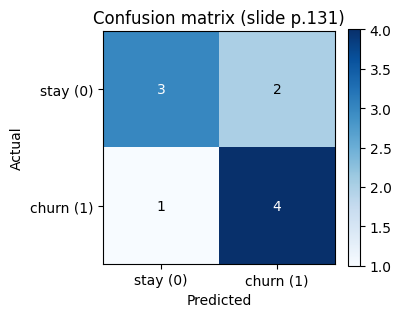

In [8]:
from nnlab.metrics import confusion_matrix
from sklearn import metrics as skm

cm = np.zeros((2, 2), dtype=int)                          # cm: (C, C) = (2, 2)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1                                          # แถว = actual t, คอลัมน์ = predicted p
print("cm (แถว actual 0/1, คอลัมน์ predicted 0/1):\n", cm)
print(f"TN = cm[0,0] = {cm[0,0]} | FP = cm[0,1] = {cm[0,1]} | FN = cm[1,0] = {cm[1,0]} | TP = cm[1,1] = {cm[1,1]}")

assert np.array_equal(cm, confusion_matrix(y_true, y_pred))
assert np.array_equal(cm, skm.confusion_matrix(y_true, y_pred))
print("ตรงกับ nnlab และ sklearn ✓")

from nnlab.plotting import plot_confusion
fig, ax = plt.subplots(figsize=(4, 3.5))
plot_confusion(cm, labels=["stay (0)", "churn (1)"], ax=ax, title="Confusion matrix (slide p.131)")
plt.tight_layout(); plt.show()

## ขั้นที่ 3 · metric ทั้ง 5 จาก TP / FP / TN / FN (สไลด์ p.132-136)
ทุก metric เป็นแค่ "สัดส่วน" ที่เลือกตัวเศษ/ตัวส่วนต่างกันจาก 4 ตัวเลขนี้ — คำถามที่แต่ละตัวตอบต่างกัน

| metric | สูตร | ตอบคำถาม | สไลด์ |
|---|---|---|---|
| accuracy | $\dfrac{TP + TN}{TP + FP + TN + FN}$ | ทายถูกกี่ส่วนจากทั้งหมด | p.132 |
| precision (PPV) | $\dfrac{TP}{TP + FP}$ | ที่ทายว่า positive มีของจริงกี่ส่วน | p.133 |
| recall (sensitivity, TPR) | $\dfrac{TP}{TP + FN}$ | positive จริงทั้งหมด จับได้กี่ส่วน | p.134 |
| specificity (TNR) | $\dfrac{TN}{TN + FP}$ | negative จริงทั้งหมด ทายถูกกี่ส่วน | p.135 |
| F1 | $\dfrac{2}{1/P + 1/R} = \dfrac{2PR}{P + R}$ | harmonic mean ของ precision กับ recall — สูงเมื่อทั้งคู่สูง | p.136 |

ทำไม F1 ใช้ harmonic mean ไม่ใช่ค่าเฉลี่ยธรรมดา: ถ้า P = 1.0 แต่ R = 0.1 ค่าเฉลี่ยธรรมดา = 0.55 ดูพอใช้ แต่ harmonic mean = 0.18 — มันลงโทษกรณีที่ตัวใดตัวหนึ่งต่ำมาก
cell นี้คำนวณจาก 4 ตัวเลขของ p.131 แล้วเทียบกับ `nnlab.metrics` และ `sklearn.metrics` ทีละตัว

In [9]:
from nnlab import metrics as nm

TP, FP, TN, FN = counts["TP"], counts["FP"], counts["TN"], counts["FN"]
acc  = (TP + TN) / (TP + FP + TN + FN)
prec = TP / (TP + FP)
rec  = TP / (TP + FN)
spec = TN / (TN + FP)
f1   = 2 * prec * rec / (prec + rec)

rows = [
    ("accuracy",    acc,  nm.accuracy(y_true, y_pred),    skm.accuracy_score(y_true, y_pred)),
    ("precision",   prec, nm.precision(y_true, y_pred),   skm.precision_score(y_true, y_pred)),
    ("recall",      rec,  nm.recall(y_true, y_pred),      skm.recall_score(y_true, y_pred)),
    ("specificity", spec, nm.specificity(y_true, y_pred), skm.recall_score(y_true, y_pred, pos_label=0)),  # sklearn ไม่มี specificity ตรงๆ = recall ของ class 0
    ("f1",          f1,   nm.f1(y_true, y_pred),          skm.f1_score(y_true, y_pred)),
]
print(f"{'metric':<12}{'มือ':>8}{'nnlab':>8}{'sklearn':>9}")
for name, a, b, c in rows:
    assert np.isclose(a, b) and np.isclose(a, c)
    print(f"{name:<12}{a:>8.4f}{b:>8.4f}{c:>9.4f}")
print(f"\nค่าเฉลี่ยธรรมดาของ P,R = {(prec + rec) / 2:.4f} แต่ F1 (harmonic) = {f1:.4f}")
print("P=1.0, R=0.1 → mean =", (1.0 + 0.1) / 2, "| F1 =", round(2 * 1.0 * 0.1 / 1.1, 3))

metric           มือ   nnlab  sklearn
accuracy      0.7000  0.7000   0.7000
precision     0.6667  0.6667   0.6667
recall        0.8000  0.8000   0.8000
specificity   0.6000  0.6000   0.6000
f1            0.7273  0.7273   0.7273

ค่าเฉลี่ยธรรมดาของ P,R = 0.7333 แต่ F1 (harmonic) = 0.7273
P=1.0, R=0.1 → mean = 0.55 | F1 = 0.182


### metric ไหนสำหรับปัญหาไหน (สไลด์ p.137-138)
คำตอบของ "โมเดลดีพอหรือยัง" ขึ้นกับว่าความผิดพลาดแบบไหน**แพงกว่า** — FP หรือ FN

| ปัญหา | ความผิดพลาดที่แพง | metric ที่ควรดู | เหตุผล |
|---|---|---|---|
| fraud detection, disease detection, churn | FN (ปล่อยของจริงหลุด) | **recall** | พลาดผู้ป่วย/ธุรกรรมโกง 1 ราย แพงกว่าตรวจซ้ำ 10 ราย |
| spam detection, search engine | FP (จับผิดตัว) | **precision** | เมลสำคัญโดนโยนลง spam / ผลค้นหาที่ไม่เกี่ยวโผล่มา ทำให้ผู้ใช้เลิกเชื่อระบบ |
| drug test | FP | **specificity** | ต้องแน่ใจว่าคนที่ไม่ได้ใช้ยาไม่ถูกกล่าวหา |
| animal classification (class สมดุล, FP/FN แพงเท่ากัน) | — | **accuracy** | p.132: "distinguishing male and female chicks" |
| class ไม่สมดุล และ FP/FN สำคัญทั้งคู่ | ทั้งคู่ | **F1** | accuracy จะถูก class ใหญ่ครอบ (ทาย "ไม่ churn" ทุกคนได้ 0.69) |

### model selection ภายใต้ข้อจำกัด (สไลด์ p.139)
สไลด์ p.139: ระบบคัดกรอง Covid-19 จาก X-ray ที่สนามบิน มีผู้โดยสารมาทุก 3 นาที — เราต้องการ sensitivity (recall) สูงสุด **ภายใต้เงื่อนไข** runtime ≤ 3 นาที
นี่คือหลัก "maximize objective subject to constraints": ตัดตัวเลือกที่ผิดข้อจำกัดออกก่อน แล้วค่อยเลือกตัวที่ objective ดีที่สุด

In [10]:
df_models = pd.DataFrame({"classifier": ["A", "B", "C"],
                          "sensitivity": [0.90, 0.92, 0.95],
                          "runtime_min": [2.0, 2.5, 5.0]}).set_index("classifier")
display(df_models)

feasible = df_models[df_models["runtime_min"] <= 3.0]          # ข้อจำกัด: ต้องเสร็จก่อนผู้โดยสารคนถัดไป (3 นาที)
best = feasible["sensitivity"].idxmax()                        # objective: sensitivity สูงสุด
print("ผ่านข้อจำกัด runtime ≤ 3 นาที:", feasible.index.tolist())
print(f"เลือก {best} (sensitivity {feasible.loc[best, 'sensitivity']:.0%}) — C แม่นกว่าแต่ช้าเกิน 3 นาที จึงใช้ไม่ได้ (สไลด์ p.139: choose B)")

,sensitivity,runtime_min
classifier,,
A,0.90,2.0
B,0.92,2.5
C,0.95,5.0


ผ่านข้อจำกัด runtime ≤ 3 นาที: ['A', 'B']
เลือก B (sensitivity 92%) — C แม่นกว่าแต่ช้าเกิน 3 นาที จึงใช้ไม่ได้ (สไลด์ p.139: choose B)


## ขั้นที่ 4 · threshold τ และ ROC curve (สไลด์ p.140-141)
perceptron/logistic regression ไม่ได้ทาย 0/1 ตรงๆ แต่ให้ **ความน่าจะเป็น** $P(y=1\mid x) = \sigma(z)$ แล้วเราตัดสินด้วย threshold: ทายว่า positive เมื่อ $P \ge \tau$
ค่า default $\tau = 0.5$ ไม่ได้ศักดิ์สิทธิ์อะไร — ลด $\tau$ ก็จับ positive ได้มากขึ้น (recall ↑) แต่จับผิดมากขึ้นด้วย (FP ↑)
**ROC curve** วาดผลของทุก $\tau$ พร้อมกัน: แกน y = TPR (= recall), แกน x = FPR (= 1 − specificity)
- $\tau = 1$: ไม่มีอะไรถึงเกณฑ์ → ทายว่า negative ทั้งหมด → TP = FP = 0 → จุด (0, 0)
- $\tau = 0$: ทุกอย่างถึงเกณฑ์ → ทายว่า positive ทั้งหมด → TPR = FPR = 1 → จุด (1, 1)
- โมเดลที่ดีคือเส้นที่ "ดันขึ้นมุมซ้ายบน" (TPR สูงขณะ FPR ยังต่ำ) เส้นทแยงคือโมเดลสุ่ม; **AUC** = พื้นที่ใต้เส้น (1.0 สมบูรณ์แบบ, 0.5 สุ่ม)

เราใช้ breast cancer dataset (569 ตัวอย่าง, 30 feature, positive = malignant) เทรน Perceptron แล้วเก็บความน่าจะเป็นของ test set ไว้กวาด $\tau$

In [11]:
from nnlab.data import load_breast_cancer_scaled

Xb_tr, Xb_te, yb_tr, yb_te = load_breast_cancer_scaled()     # Xb_tr: (456, 30) | Xb_te: (113, 30) normalize แล้ว
clf = Perceptron(lr=0.1, epochs=500).fit(Xb_tr, yb_tr)
scores = clf.predict_proba(Xb_te)                            # scores: (113,) = P(y=1|x)
print("test:", Xb_te.shape, "| positive (malignant) =", yb_te.sum(), "| negative =", (yb_te == 0).sum())
print("P(y=1|x) ของ 8 ตัวแรก:", scores[:8].round(3), "| label จริง:", yb_te[:8])
print("ที่ τ = 0.5:", clf.evaluate(Xb_te, yb_te))

test: (113, 30) | positive (malignant) = 42 | negative = 71
P(y=1|x) ของ 8 ตัวแรก: [0.002 0.    0.257 0.98  0.013 0.    0.102 0.   ] | label จริง: [0 0 0 1 0 0 0 0]
ที่ τ = 0.5: {'tp': 40, 'fp': 4, 'tn': 67, 'fn': 2, 'accuracy': 0.9469026548672567, 'precision': 0.9090909090909091, 'recall': 0.9523809523809523, 'specificity': 0.9436619718309859, 'f1': 0.9302325581395349}


กวาด $\tau$ = 0, 0.05, …, 1 (21 ค่า) — ทุกค่านับ TP, FP แล้วคิด TPR = TP / #positive, FPR = FP / #negative
ดูสองปลายตาราง: แถว $\tau=1$ ต้องเป็น (0, 0) และแถว $\tau=0$ ต้องเป็น (1, 1) ตามสไลด์ p.141

In [12]:
n_pos, n_neg = (yb_te == 1).sum(), (yb_te == 0).sum()
taus = np.linspace(0, 1, 21)                                  # (21,)
rows = []
for tau in taus:
    pred = (scores >= tau).astype(int)                        # (113,)
    tp = np.sum((pred == 1) & (yb_te == 1)); fp = np.sum((pred == 1) & (yb_te == 0))
    rows.append({"tau": tau, "TP": tp, "FP": fp, "TPR": tp / n_pos, "FPR": fp / n_neg})
df_roc = pd.DataFrame(rows).set_index("tau")
display(df_roc.round(3))
print(f"τ = 1 → (FPR, TPR) = ({df_roc.loc[1.0, 'FPR']:.0f}, {df_roc.loc[1.0, 'TPR']:.0f}) | τ = 0 → ({df_roc.loc[0.0, 'FPR']:.0f}, {df_roc.loc[0.0, 'TPR']:.0f})   ← ตรงกับสไลด์ p.141")

,TP,FP,TPR,FPR
tau,,,,
0.00,42,71,1.000,1.000
0.05,42,19,1.000,0.268
0.10,42,12,1.000,0.169
0.15,41,8,0.976,0.113
0.20,41,7,0.976,0.099
0.25,41,7,0.976,0.099
0.30,41,5,0.976,0.070
0.35,40,5,0.952,0.070
0.40,40,5,0.952,0.070


τ = 1 → (FPR, TPR) = (0, 0) | τ = 0 → (1, 1)   ← ตรงกับสไลด์ p.141


เขียนฟังก์ชัน `roc_inline` จาก loop ด้านบน และ AUC ด้วยกฎสี่เหลี่ยมคางหมู (trapezoid) $\sum_i (x_{i+1} - x_i)\,\frac{y_i + y_{i+1}}{2}$ หลังเรียงจุดตาม FPR
แล้วเทียบกับ `nnlab.metrics.roc_curve/auc` และ `sklearn.metrics.roc_curve/roc_auc_score`
หมายเหตุ: sklearn ใช้ทุกค่า score ที่ไม่ซ้ำเป็น threshold (ละเอียดกว่า 21 จุด) AUC จึงต่างจากแบบ 21 จุดเล็กน้อย — เราเทียบ `nnlab` แบบ default (ก็ใช้ทุกค่าไม่ซ้ำ) กับ sklearn ให้ตรงกันแทน

AUC จาก 21 จุด (มือ)       = 0.9811
AUC nnlab (ทุก threshold)   = 0.9950  (115 จุด)
AUC sklearn                 = 0.9950  (10 จุด)
roc_inline ตรงกับ nnlab.roc_curve(thresholds=taus) ✓ | AUC nnlab ตรงกับ sklearn ✓


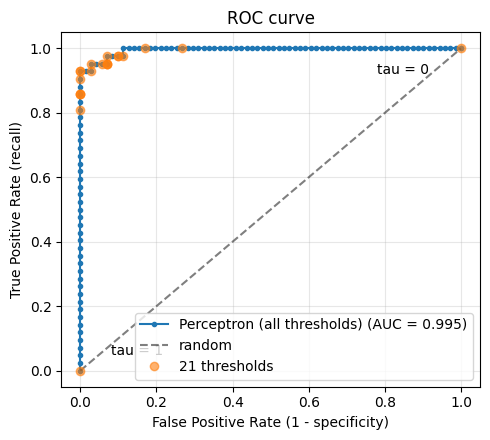

In [13]:
def roc_inline(y, s, thresholds):
    tpr, fpr = [], []
    for tau in thresholds:
        pred = (s >= tau).astype(int)
        tpr.append(np.sum((pred == 1) & (y == 1)) / np.sum(y == 1))
        fpr.append(np.sum((pred == 1) & (y == 0)) / np.sum(y == 0))
    return np.array(fpr), np.array(tpr)

def auc_inline(fpr, tpr):
    order = np.argsort(fpr, kind="stable")                    # เรียงให้ x เพิ่มขึ้น
    x, y = fpr[order], tpr[order]
    return float(np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2))

fpr21, tpr21 = roc_inline(yb_te, scores, taus)
print(f"AUC จาก 21 จุด (มือ)       = {auc_inline(fpr21, tpr21):.4f}")

fpr_nn, tpr_nn, thr_nn = nm.roc_curve(yb_te, scores)          # default: threshold = ทุกค่า score ที่ไม่ซ้ำ + ∞/−∞
auc_nn = nm.auc(fpr_nn, tpr_nn)
fpr_sk, tpr_sk, thr_sk = skm.roc_curve(yb_te, scores)
auc_sk = skm.roc_auc_score(yb_te, scores)
print(f"AUC nnlab (ทุก threshold)   = {auc_nn:.4f}  ({len(thr_nn)} จุด)")
print(f"AUC sklearn                 = {auc_sk:.4f}  ({len(thr_sk)} จุด)")
assert np.isclose(auc_nn, auc_sk) and np.isclose(auc_inline(fpr_nn, tpr_nn), auc_sk)
fpr21_nn, tpr21_nn, _ = nm.roc_curve(yb_te, scores, thresholds=taus)
assert np.allclose(fpr21, fpr21_nn) and np.allclose(tpr21, tpr21_nn)
print("roc_inline ตรงกับ nnlab.roc_curve(thresholds=taus) ✓ | AUC nnlab ตรงกับ sklearn ✓")

from nnlab.plotting import plot_roc
fig, ax = plt.subplots(figsize=(5, 4.5))
plot_roc(fpr_nn, tpr_nn, auc_nn, ax=ax, label="Perceptron (all thresholds)")
ax.plot(fpr21, tpr21, "o", alpha=0.6, label="21 thresholds")
ax.annotate("tau = 1", (0, 0), xytext=(0.08, 0.05)); ax.annotate("tau = 0", (1, 1), xytext=(0.78, 0.92))
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

## ขั้นที่ 5 · multiclass: micro average กับ macro average (สไลด์ p.142-151)
เมื่อมีมากกว่า 2 class (Virus / Bacteria / Fungus) confusion matrix กลายเป็น 3×3 และ "positive" ไม่มีตัวเดียวอีกแล้ว
วิธีแก้คือมองทีละ class แบบ **one-vs-rest**: ตอนคิดของ class V ให้ V เป็น positive และ B, F รวมกันเป็น negative → ได้ $TP_V, FP_V, FN_V, TN_V$ จาก matrix เดียวกัน

$$TP_c = \text{cm}[c,c] \qquad FP_c = \sum_{\text{แถว}} \text{cm}[:,c] - TP_c \qquad FN_c = \sum_{\text{คอลัมน์}} \text{cm}[c,:] - TP_c \qquad TN_c = N - TP_c - FP_c - FN_c$$

cell นี้ใช้ confusion matrix ของสไลด์ p.144 (แถว = actual, คอลัมน์ = predicted, ลำดับ V, B, F) แล้วพิมพ์ 4 ตัวเลขของทุก class แบบสไลด์

In [14]:
labels_vbf = ["Virus", "Bacteria", "Fungus"]
cm3 = np.array([[16, 0, 5],
                [ 0, 14, 0],
                [ 1, 1, 6]])                                  # cm3: (C, C) = (3, 3) แถว actual, คอลัมน์ predicted
N = cm3.sum()
print("cm (rows actual V,B,F / cols predicted V,B,F):\n", cm3, "\nรวม N =", N, "sample")

per_class = {}
for c, name in enumerate(labels_vbf):
    tp = cm3[c, c]
    fp = cm3[:, c].sum() - tp                                 # คอลัมน์ c: ถูกทายว่าเป็น c แต่จริงไม่ใช่
    fn = cm3[c, :].sum() - tp                                 # แถว c: จริงเป็น c แต่ถูกทายเป็นอย่างอื่น
    tn = N - tp - fp - fn
    per_class[name] = {"TP": tp, "FP": fp, "FN": fn, "TN": tn}
    print(f"Class {name[0]}: TP_{name[0]} = {tp:2d}  FP_{name[0]} = {fp}  FN_{name[0]} = {fn}  TN_{name[0]} = {tn}")
print("\nหมายเหตุ: สไลด์ p.144 เขียน TN_B = 16 + 6 + 1 + 6 = 29 แต่ช่องที่เหลือของ B คือ 16, 5, 1, 6 → TN_B =", per_class["Bacteria"]["TN"])

cm (rows actual V,B,F / cols predicted V,B,F):
 [[16  0  5]
 [ 0 14  0]
 [ 1  1  6]] 
รวม N = 43 sample
Class V: TP_V = 16  FP_V = 1  FN_V = 5  TN_V = 21
Class B: TP_B = 14  FP_B = 1  FN_B = 0  TN_B = 28
Class F: TP_F =  6  FP_F = 5  FN_F = 2  TN_F = 30

หมายเหตุ: สไลด์ p.144 เขียน TN_B = 16 + 6 + 1 + 6 = 29 แต่ช่องที่เหลือของ B คือ 16, 5, 1, 6 → TN_B = 28


### micro average (p.144-147): รวมตัวเลขก่อน แล้วค่อยหาร
$$\text{precision}_{micro} = \frac{\sum_c TP_c}{\sum_c TP_c + \sum_c FP_c} = \frac{16+14+6}{(16+14+6) + (1+1+5)} = \frac{36}{43}$$
สังเกตว่า $\sum_c FP_c = \sum_c FN_c$ เสมอ (ทุก sample ที่ทายผิดเป็น FP ของ class หนึ่งและ FN ของอีก class หนึ่ง) ดังนั้น
**micro precision = micro recall = micro F1 = accuracy** = 36/43 ≈ 0.837 — สไลด์ p.147 จึงบอกว่า "there is no micro average for accuracy" (มันคือค่าเดียวกัน)

In [15]:
TPs = np.array([v["TP"] for v in per_class.values()])          # (3,)
FPs = np.array([v["FP"] for v in per_class.values()])
FNs = np.array([v["FN"] for v in per_class.values()])
print("ΣTP =", TPs.sum(), "| ΣFP =", FPs.sum(), "| ΣFN =", FNs.sum(), "  ← ΣFP = ΣFN เสมอ")

micro_p = TPs.sum() / (TPs.sum() + FPs.sum())
micro_r = TPs.sum() / (TPs.sum() + FNs.sum())
micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r)
accuracy3 = np.trace(cm3) / N
print(f"micro precision = {micro_p:.4f} | micro recall = {micro_r:.4f} | micro F1 = {micro_f1:.4f} | accuracy = {accuracy3:.4f}  (= 36/43)")
assert np.isclose(micro_p, 36 / 43) and np.isclose(micro_f1, accuracy3)

ΣTP = 36 | ΣFP = 7 | ΣFN = 7   ← ΣFP = ΣFN เสมอ
micro precision = 0.8372 | micro recall = 0.8372 | micro F1 = 0.8372 | accuracy = 0.8372  (= 36/43)


### macro average (p.148-151): คิด metric ของแต่ละ class ก่อน แล้วเฉลี่ยเท่ากันทุก class
$$\text{precision}_{macro} = \frac{1}{C}\sum_c \frac{TP_c}{TP_c + FP_c} = \frac{1}{3}\left(\frac{16}{17} + \frac{14}{15} + \frac{6}{11}\right)$$

> **errata สไลด์ p.148-151:** หน้าที่ชื่อ "Macro Average" ใส่สูตรของ micro ซ้ำ (จึงได้ 36/43 = 0.837 ทุกตัว) ค่าที่ถูกต้องคำนวณสดใน cell ถัดไป:
> macro precision ≈ **0.807**, macro recall ≈ **0.837** (ใกล้ micro โดยบังเอิญ), macro F1 ≈ **0.813**

ทำไมต่างจาก micro: Fungus มีแค่ 8 sample และ precision ต่ำ (6/11) — ใน micro มันถูก "กลบ" ด้วย V และ B ที่มีเยอะกว่า แต่ใน macro ทุก class มีน้ำหนัก 1/3 เท่ากัน
เราเทียบกับ `nnlab.metrics.per_class_counts / multiclass_report` และกับ `sklearn.metrics.classification_report` โดยสร้าง label กลับจาก confusion matrix ด้วย `np.repeat`

In [16]:
P_c = TPs / (TPs + FPs)                                       # (3,) precision ต่อ class
R_c = TPs / (TPs + FNs)                                       # (3,) recall ต่อ class
F1_c = 2 * P_c * R_c / (P_c + R_c)                            # (3,)
df_cls = pd.DataFrame({"TP": TPs, "FP": FPs, "FN": FNs, "precision": P_c, "recall": R_c, "f1": F1_c}, index=labels_vbf)
display(df_cls.round(4))

macro_p, macro_r, macro_f1 = P_c.mean(), R_c.mean(), F1_c.mean()
print(f"macro precision = {macro_p:.4f} (สไลด์เขียน 0.837 — ผิด)")
print(f"macro recall    = {macro_r:.4f} (บังเอิญ ≈ micro {micro_r:.4f})")
print(f"macro F1        = {macro_f1:.4f} (สไลด์เขียน 0.837 — ผิด)")

# เทียบ nnlab
c_nn = nm.per_class_counts(cm3)
assert np.array_equal(c_nn["tp"], TPs) and np.array_equal(c_nn["fp"], FPs) and np.array_equal(c_nn["fn"], FNs)
rep_macro, rep_micro = nm.multiclass_report(cm3, "macro"), nm.multiclass_report(cm3, "micro")
assert np.isclose(rep_macro["precision"], macro_p) and np.isclose(rep_macro["f1"], macro_f1) and np.isclose(rep_micro["f1"], micro_f1)
print("\nnnlab macro:", {k: round(v, 4) for k, v in rep_macro.items()})
print("nnlab micro:", {k: round(v, 4) for k, v in rep_micro.items()})

# เทียบ sklearn: สร้าง y_true/y_pred ที่ให้ confusion matrix นี้พอดี
y_true3 = np.repeat(np.arange(3), cm3.sum(axis=1))                                   # (43,) แถว i ซ้ำตามจำนวนในแถว
y_pred3 = np.concatenate([np.repeat(np.arange(3), cm3[i]) for i in range(3)])        # (43,) ในแต่ละแถว ทายเป็น j ซ้ำ cm[i, j] ครั้ง
assert np.array_equal(skm.confusion_matrix(y_true3, y_pred3), cm3)
print("\n", skm.classification_report(y_true3, y_pred3, target_names=labels_vbf, digits=3))
assert np.isclose(skm.f1_score(y_true3, y_pred3, average="macro"), macro_f1)
assert np.isclose(skm.f1_score(y_true3, y_pred3, average="micro"), micro_f1)

,TP,FP,FN,precision,recall,f1
Virus,16,1,5,0.9412,0.7619,0.8421
Bacteria,14,1,0,0.9333,1.0000,0.9655
Fungus,6,5,2,0.5455,0.7500,0.6316


macro precision = 0.8067 (สไลด์เขียน 0.837 — ผิด)
macro recall    = 0.8373 (บังเอิญ ≈ micro 0.8372)
macro F1        = 0.8131 (สไลด์เขียน 0.837 — ผิด)

nnlab macro: {'accuracy': 0.8372, 'precision': 0.8067, 'recall': 0.8373, 'f1': 0.8131}
nnlab micro: {'accuracy': 0.8372, 'precision': 0.8372, 'recall': 0.8372, 'f1': 0.8372}

               precision    recall  f1-score   support

       Virus      0.941     0.762     0.842        21
    Bacteria      0.933     1.000     0.966        14
      Fungus      0.545     0.750     0.632         8

    accuracy                          0.837        43
   macro avg      0.807     0.837     0.813        43
weighted avg      0.865     0.837     0.843        43



## ขั้นที่ 6 · ประเมินโมเดล multiclass จริง: NeuralNetwork บน digits
ทีนี้เอาทุกอย่างมาใช้กับโมเดลจริง: `NeuralNetwork([64, 32, 10])` จาก lab07 (optimizer adam, mini-batch 64) บนภาพตัวเลข 8×8 ของ scikit-learn (10 class)
`get_dataset("digits")` แบ่ง 80:20 แบบ stratified และ normalize ให้แล้ว เราจะดู confusion matrix 10×10, micro/macro จาก `nnlab.metrics.multiclass_report`
และ recall ต่อ class เพื่อหาว่าตัวเลขไหนโมเดลจับได้แย่ที่สุด — สิ่งที่ accuracy ตัวเดียวบอกไม่ได้

train (1438, 64) | test (359, 64) | classes 10 | test ต่อ class: [36 36 35 37 36 36 36 36 35 36]


train cost 0.0462 | test accuracy 0.9666


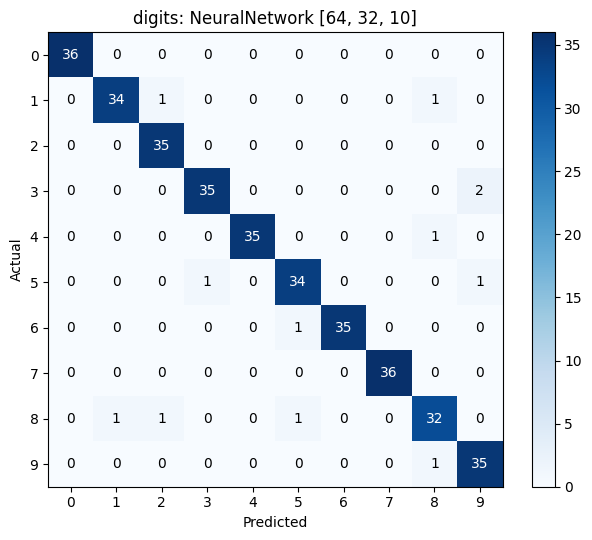

micro: {'accuracy': 0.9666, 'precision': 0.9666, 'recall': 0.9666, 'f1': 0.9666}
macro: {'accuracy': 0.9666, 'precision': 0.9669, 'recall': 0.9666, 'f1': 0.9665}
recall ต่อ class: [1.    0.944 1.    0.946 0.972 0.944 0.972 1.    0.914 0.972] | แย่สุด = digit 8
คู่ที่สับสนบ่อยสุด: จริง 3 → ทาย 9 (2 ครั้ง)


In [17]:
from nnlab.nn import NeuralNetwork

Xd_tr, Xd_te, yd_tr, yd_te, C = get_dataset("digits")        # Xd_tr: (1438, 64) | Xd_te: (359, 64) | C = 10
print("train", Xd_tr.shape, "| test", Xd_te.shape, "| classes", C, "| test ต่อ class:", np.bincount(yd_te))

net = NeuralNetwork([64, 32, 10], optimizer="adam", lr=0.001, epochs=40, batch_size=64)
net.fit(Xd_tr, yd_tr)                                         # เทรนด้วย train เท่านั้น — test เก็บไว้วัดครั้งเดียว
yd_pred = net.predict(Xd_te)                                  # (359,) argmax ของ softmax
print(f"train cost {net.history_['cost'][-1]:.4f} | test accuracy {nm.accuracy(yd_te, yd_pred):.4f}")

cm10 = nm.confusion_matrix(yd_te, yd_pred, n_classes=10)      # cm10: (10, 10)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_confusion(cm10, ax=ax, title="digits: NeuralNetwork [64, 32, 10]")
plt.tight_layout(); plt.show()

macro10, micro10 = nm.multiclass_report(cm10, "macro"), nm.multiclass_report(cm10, "micro")
print("micro:", {k: round(v, 4) for k, v in micro10.items()})
print("macro:", {k: round(v, 4) for k, v in macro10.items()})
c10 = nm.per_class_counts(cm10)
recall_c = c10["tp"] / (c10["tp"] + c10["fn"])                # (10,)
print("recall ต่อ class:", recall_c.round(3), "| แย่สุด = digit", recall_c.argmin())
off = cm10.copy(); np.fill_diagonal(off, 0)
i, j = np.unravel_index(off.argmax(), off.shape)
print(f"คู่ที่สับสนบ่อยสุด: จริง {i} → ทาย {j} ({off[i, j]} ครั้ง)")

## ขั้นที่ 7 · เวอร์ชัน production ใน `nnlab`
โค้ดที่เราเพิ่งเขียนใน cell ด้านบนคือ "โค้ดเพื่อความเข้าใจ" — แยกทุกขั้นให้เห็น
ในการใช้งานจริง โค้ดเดียวกันถูกจัดเป็นฟังก์ชัน/คลาสใน `src/nnlab/metrics.py` พร้อม docstring, type hints และ test
cell ถัดไปเรียกเวอร์ชัน production มาเทียบกับที่เราเขียนเอง (confusion_matrix, binary_report, roc_curve/auc, multiclass_report) — ตัวเลขต้องตรงกัน
เปิดไฟล์ `src/nnlab/metrics.py` ควบคู่กันเพื่อดูว่าโค้ด "ทดลอง" กลายเป็นโค้ด "ใช้งานจริง" ได้อย่างไร

In [18]:
from nnlab.metrics import binary_report, roc_curve, auc, multiclass_report

# binary: ตัวเลขสไลด์ p.131 ที่เรานับด้วย loop
rep = binary_report(y_true, y_pred)
mine = {"tp": TP, "fp": FP, "tn": TN, "fn": FN, "accuracy": acc, "precision": prec, "recall": rec, "specificity": spec, "f1": f1}
for k, v in mine.items():
    assert np.isclose(rep[k], v), k
print("binary_report:", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in rep.items()})

# ROC/AUC: breast cancer
fpr_p, tpr_p, _ = roc_curve(yb_te, scores, thresholds=taus)
assert np.allclose(fpr_p, fpr21) and np.allclose(tpr_p, tpr21) and np.isclose(auc(fpr_p, tpr_p), auc_inline(fpr21, tpr21))
print(f"roc_curve/auc (21 threshold): AUC = {auc(fpr_p, tpr_p):.4f} ตรงกับที่เขียนเอง")

# multiclass: ตาราง V/B/F
assert np.isclose(multiclass_report(cm3, "macro")["f1"], macro_f1) and np.isclose(multiclass_report(cm3, "micro")["f1"], micro_f1)
print(f"multiclass_report: macro F1 = {multiclass_report(cm3, 'macro')['f1']:.4f} | micro F1 = {multiclass_report(cm3, 'micro')['f1']:.4f} ตรงกับที่เขียนเอง ✓")

binary_report: {'tp': 4, 'fp': 2, 'tn': 3, 'fn': 1, 'accuracy': 0.7, 'precision': 0.6667, 'recall': 0.8, 'specificity': 0.6, 'f1': 0.7273}
roc_curve/auc (21 threshold): AUC = 0.9811 ตรงกับที่เขียนเอง
multiclass_report: macro F1 = 0.8131 | micro F1 = 0.8372 ตรงกับที่เขียนเอง ✓


## ★ Key Takeaways
- แบ่งข้อมูลแบบ stratified: train ใช้เรียน, validation ใช้เลือก hyperparameter, test ใช้รายงานผล**ครั้งเดียว**; k-fold ให้คะแนน k ค่าและรายงานเป็น mean ± std
- positive class = class ที่สนใจจับ; ทุก metric มาจาก 4 ตัวเลข TP / FP / TN / FN ของ confusion matrix (แถว = actual, คอลัมน์ = predicted — ดูลำดับ class ของ library ก่อนอ่านเสมอ)
- เลือก metric ตามว่าความผิดพลาดแบบไหนแพง: FN แพง → recall (โรค, fraud, churn) · FP แพง → precision (spam, search) / specificity (drug test) · class ไม่สมดุล → F1 · เลือกโมเดลแบบ maximize objective **subject to constraints**
- threshold τ ปรับได้ ไม่จำเป็นต้อง 0.5; ROC วาด (FPR, TPR) ของทุก τ จาก (0,0) ที่ τ=1 ถึง (1,1) ที่ τ=0 และ AUC สรุปเป็นเลขเดียว
- multiclass ใช้ one-vs-rest ต่อ class: micro = รวม TP/FP/FN ก่อนหาร (= accuracy เสมอ) · macro = เฉลี่ย metric ต่อ class (class เล็กมีน้ำหนักเท่า class ใหญ่) — ค่าที่ถูกของสไลด์ p.148-151 คือ macro P 0.807 / R 0.837 / F1 0.813
- `nnlab.metrics` ให้ผลตรงกับ `sklearn.metrics` ทุกตัว — โค้ดที่นิสิตเขียนใน lab นี้คือสิ่งที่ library ทำอยู่ข้างใน

## แบบฝึกหัด (ทำเอง)
ส่วนนี้ต้อง**เขียนโค้ดเอง** — แต่ละข้อมี 3 cell: โจทย์ (อ่านให้จบก่อน) → cell โครง (มี `raise NotImplementedError` ให้แทนที่ด้วยโค้ดของคุณ) → cell ตรวจคำตอบ
cell ตรวจคำตอบรันได้ทันที: ถ้ายังไม่ได้ทำจะขึ้น ⏳ ถ้าผิดจะขึ้น ✗ พร้อมคำใบ้ ถ้าถูกจะขึ้น ✓ PASS
ทำได้ไม่จำกัดรอบ แก้แล้วรัน cell โครงและ cell ตรวจซ้ำ ใช้ผลจาก cell ก่อนหน้าใน lab นี้ได้ทุกตัว

In [19]:
from nnlab.exercise import check, check_close, check_shape, summary, reset
reset()   # ล้างผลการตรวจเก่าใน kernel นี้

### แบบฝึกหัด 10.1 · หา threshold τ ที่ให้ F1 สูงสุด
**เป้าหมาย:** เติมโค้ดใน `best_threshold` ให้กวาด τ ทุกค่าใน grid แล้วคืน τ ที่ F1 สูงสุด — เพื่อดูว่า τ = 0.5 ไม่ใช่ค่าที่ดีที่สุดเสมอ

**ขั้นตอน**
1. ใน loop: คำนวณ F1 ของ `pred` ด้วย `nm.f1(y, pred)` แล้ว `append` ลง `f1s` (แทนที่ `raise` บรรทัดแรก)
2. หลัง loop: `idx = int(np.argmax(f1s))` แล้วคืน `(grid[idx], f1s[idx])` (แทนที่ `raise` บรรทัดที่สอง)
3. ทดสอบกับ `scores`, `yb_te` ของ breast cancer (ขั้นที่ 4) และ `grid_101` — เทียบ F1 ที่ได้กับ F1 ที่ τ = 0.5 จาก `clf.evaluate(Xb_te, yb_te)` แล้วดู precision/recall ที่ τ ใหม่ด้วย `nm.binary_report(yb_te, (scores >= tau_b).astype(int))`

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- บรรทัดแรก: `f1s.append(nm.f1(y, pred))`
- `np.argmax` คืนตำแหน่ง (index) ไม่ใช่ค่า — เอา index ไปดึงทั้ง grid และ f1s
</details>

In [20]:
# --- แบบฝึกหัด 10.1: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def best_threshold(y, s, grid):
    """คืน (tau_best, f1_best): τ ใน grid ที่ให้ F1 สูงสุด   y: (m,) label 0/1   s: (m,) P(y=1|x)   grid: (k,)"""
    f1s = []
    for tau in grid:
        pred = (s >= tau).astype(int)                 # (m,) ทำนาย positive เมื่อ P ≥ τ
        raise NotImplementedError("ยังไม่ได้ทำ")     # TODO: F1 ของ pred → append ลง f1s
    raise NotImplementedError("ยังไม่ได้ทำ")         # TODO: index ที่ F1 สูงสุด → คืน (grid[idx], f1s[idx])

grid_101 = np.linspace(0, 1, 101)                     # (101,) τ = 0, 0.01, ..., 1
# ตัวอย่างการเรียก: tau_b, f1_b = best_threshold(yb_te, scores, grid_101); print(tau_b, f1_b)

In [21]:
# --- ตรวจคำตอบ 10.1 (รันได้ทันที ไม่ต้องแก้) ---
def _bt_101():
    return best_threshold(yb_te, scores, grid_101)

def _f1_sk(tau):                                       # อ้างอิงจาก sklearn (คนละทางกับ nm.f1)
    return skm.f1_score(yb_te, (scores >= tau).astype(int), zero_division=0)

check("10.1 τ ที่คืนอยู่ใน grid", lambda: np.any(np.isclose(_bt_101()[0], grid_101)), hint="คืน grid[idx] ไม่ใช่ idx")
check("10.1 f1_best = F1 ของ sklearn ที่ τ นั้น", lambda: np.isclose(_bt_101()[1], _f1_sk(_bt_101()[0])), hint="f1s[idx] ต้องเป็น F1 ของ pred ที่ τ = grid[idx] ตัวเดียวกัน")
check_close("10.1 f1_best = ค่าสูงสุดในบรรดา 101 ค่า (sklearn)", lambda: _bt_101()[1], max(_f1_sk(t) for t in grid_101), hint="np.argmax(f1s) ให้ index ของค่าสูงสุด")
check("10.1 F1 ที่ τ ที่ได้ ≥ F1 ที่ τ = 0.5", lambda: _bt_101()[1] >= nm.f1(yb_te, (scores >= 0.5).astype(int)) - 1e-12)
check("10.1 τ ที่ดีที่สุดของ breast cancer นี้ไม่ใช่ 0.5", lambda: not np.isclose(_bt_101()[0], 0.5))

⏳ 10.1 τ ที่คืนอยู่ใน grid: ยังไม่ได้ทำ
⏳ 10.1 f1_best = F1 ของ sklearn ที่ τ นั้น: ยังไม่ได้ทำ


⏳ 10.1 f1_best = ค่าสูงสุดในบรรดา 101 ค่า (sklearn): ยังไม่ได้ทำ
⏳ 10.1 F1 ที่ τ ที่ได้ ≥ F1 ที่ τ = 0.5: ยังไม่ได้ทำ
⏳ 10.1 τ ที่ดีที่สุดของ breast cancer นี้ไม่ใช่ 0.5: ยังไม่ได้ทำ


False

### แบบฝึกหัด 10.2 · specificity ต่อ class จาก confusion matrix
**เป้าหมาย:** เขียน `specificity_per_class(cm)` ที่คืน TN_c / (TN_c + FP_c) ของทุก class แบบ one-vs-rest (สูตรขั้นที่ 5) แล้วใช้กับ `cm3` และ `cm10`

**ขั้นตอน**
1. `tp = np.diag(cm)` → (C,) ช่องทแยง
2. `fp = cm.sum(axis=0) - tp` (ผลรวมคอลัมน์ลบ TP) และ `fn = cm.sum(axis=1) - tp` (ผลรวมแถวลบ TP) — เวอร์ชัน vectorized ของ loop ในขั้นที่ 5
3. `tn = cm.sum() - tp - fp - fn` แล้วคืน `tn / (tn + fp)` เป็น array (C,)
4. ลองกับ `cm3` (ต้องได้ 21/22, 28/29, 30/35) และ `cm10` — ทำไมทุก class ของ digits จึงได้ > 0.98 ทั้งที่ recall บางตัวต่ำกว่า? (negative ของแต่ละ class มีถึง ~320 ตัว FP ไม่กี่ตัวจึงแทบไม่กระทบ)

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- 4 บรรทัดจาก `nnlab.metrics.per_class_counts` (เปิด `src/nnlab/metrics.py` ดูได้) แต่ให้เขียนเอง — ต่างจาก loop ของขั้นที่ 5 ตรงที่ทำทุก class พร้อมกันด้วย axis
- `cm.sum(axis=0)` ยุบแถว → ผลรวมของแต่ละคอลัมน์ (ถูกทายว่าเป็น c ทั้งหมด)
</details>

In [22]:
# --- แบบฝึกหัด 10.2: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def specificity_per_class(cm):
    """cm: (C, C) แถว = actual, คอลัมน์ = predicted → specificity ของแต่ละ class (C,) = TN_c / (TN_c + FP_c)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# ตัวอย่างการเรียก: print(specificity_per_class(cm3))   # คาด [0.9545 0.9655 0.8571]

In [23]:
# --- ตรวจคำตอบ 10.2 (รันได้ทันที ไม่ต้องแก้) ---
_c3, _c10 = nm.per_class_counts(cm3), nm.per_class_counts(cm10)          # อ้างอิง: nnlab แยก TP/FP/FN/TN ให้
check_shape("10.2 cm3 → shape (3,)", lambda: np.asarray(specificity_per_class(cm3)), (3,))
check_close("10.2 cm3 ตรงกับ nnlab.metrics.per_class_counts", lambda: specificity_per_class(cm3), _c3["tn"] / (_c3["tn"] + _c3["fp"]), hint="FP_c = ผลรวมคอลัมน์ c − TP_c, TN_c = N − TP_c − FP_c − FN_c")
check_close("10.2 Fungus = recall ของ 'ไม่ใช่ Fungus' (sklearn)", lambda: specificity_per_class(cm3)[2], skm.recall_score((y_true3 != 2).astype(int), (y_pred3 != 2).astype(int)), hint="specificity ของ class c คือ recall ของ 'ทุก class ที่ไม่ใช่ c'")
check_close("10.2 cm10 (digits) ตรงกับ per_class_counts", lambda: specificity_per_class(cm10), _c10["tn"] / (_c10["tn"] + _c10["fp"]))
check("10.2 digits: ทุก class specificity > 0.98", lambda: np.all(np.asarray(specificity_per_class(cm10)) > 0.98))
check_close("10.2 matrix ที่ทายถูกหมด → specificity 1 ทุก class", lambda: specificity_per_class(np.diag([5, 3, 9])), [1.0, 1.0, 1.0], hint="ไม่มี FP → TN / (TN + 0) = 1")

⏳ 10.2 cm3 → shape (3,): ยังไม่ได้ทำ
⏳ 10.2 cm3 ตรงกับ nnlab.metrics.per_class_counts: ยังไม่ได้ทำ
⏳ 10.2 Fungus = recall ของ 'ไม่ใช่ Fungus' (sklearn): ยังไม่ได้ทำ
⏳ 10.2 cm10 (digits) ตรงกับ per_class_counts: ยังไม่ได้ทำ
⏳ 10.2 digits: ทุก class specificity > 0.98: ยังไม่ได้ทำ
⏳ 10.2 matrix ที่ทายถูกหมด → specificity 1 ทุก class: ยังไม่ได้ทำ


False

### แบบฝึกหัด 10.3 · คู่ตัวเลขที่สับสนกันบ่อยที่สุด
**เป้าหมาย:** เขียน `most_confused_pairs(cm, k)` ที่รวมความสับสนสองทิศทาง cm[i, j] + cm[j, i] แล้วคืน k คู่ที่มากที่สุด — สิ่งที่ accuracy ตัวเดียวบอกไม่ได้

**ขั้นตอน**
1. วนทุกคู่ `i < j` (`for i in range(C): for j in range(i + 1, C)`) เก็บ `(i, j, cm[i, j] + cm[j, i])` ลง list (ใช้ `int(...)` ให้เป็น int ธรรมดา)
2. เรียง list ตามค่าที่สาม (จำนวน) จากมากไปน้อย: `sorted(pairs, key=lambda p: p[2], reverse=True)`
3. คืน `k` รายการแรก (`[:k]`) — ต่างจาก cell ขั้นที่ 6 ที่ดูทิศทางเดียว (`off.argmax()`)
4. ลองกับ `cm10` แล้วเปิดดูภาพจาก `nnlab.data.load_digits_images()` ว่าคู่นั้นหน้าตาคล้ายกันจริงไหม (เพิ่ม cell ใหม่: `images, yd = load_digits_images(); plt.imshow(images[yd == i][0], cmap='gray')`)

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `pairs = [(i, j, int(cm[i, j] + cm[j, i])) for i in range(C) for j in range(i + 1, C)]` แล้ว `sorted(...)[:k]`
- `C = cm.shape[0]`
</details>

In [24]:
# --- แบบฝึกหัด 10.3: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def most_confused_pairs(cm, k=3):
    """คืน list ของ (i, j, count) ยาว k เรียงจาก count มากไปน้อย โดย i < j และ count = cm[i, j] + cm[j, i]"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# ตัวอย่างการเรียก: print(most_confused_pairs(cm10, 3)); print(most_confused_pairs(cm3, 1))   # cm3 → [(0, 2, 6)]

In [25]:
# --- ตรวจคำตอบ 10.3 (รันได้ทันที ไม่ต้องแก้) ---
_S10 = cm10 + cm10.T                                                          # อ้างอิงด้วย numpy: ผลรวมสองทิศ
np.fill_diagonal(_S10, 0)                                                     # ไม่นับช่องทแยง (ทายถูก)
_top10 = np.sort(_S10[np.triu_indices(10, k=1)])[::-1]                         # count ของทุกคู่ i<j เรียงมากไปน้อย
check("10.3 คืน 3 รายการ แต่ละรายการมี 3 ค่า", lambda: len(most_confused_pairs(cm10, 3)) == 3 and all(len(p) == 3 for p in most_confused_pairs(cm10, 3)))
check("10.3 ทุกคู่มี i < j", lambda: all(p[0] < p[1] for p in most_confused_pairs(cm10, 3)), hint="วน j ตั้งแต่ i + 1 จะได้ไม่นับคู่ซ้ำและไม่นับทแยง")
check("10.3 count ของแต่ละคู่ = cm[i, j] + cm[j, i]", lambda: all(p[2] == cm10[p[0], p[1]] + cm10[p[1], p[0]] for p in most_confused_pairs(cm10, 3)))
check_close("10.3 count ของ 3 คู่แรกตรงกับ 3 ค่าสูงสุดจาก numpy", lambda: [p[2] for p in most_confused_pairs(cm10, 3)], _top10[:3], hint="เรียงด้วย reverse=True แล้วตัด [:k]")
check("10.3 cm3: คู่ที่สับสนที่สุดคือ Virus↔Fungus 6 ครั้ง (5 + 1)", lambda: tuple(int(v) for v in most_confused_pairs(cm3, 1)[0]) == (0, 2, 6))
check("10.3 k=5 คืน 5 รายการ เรียงไม่เพิ่มขึ้น", lambda: (lambda r: len(r) == 5 and all(r[a][2] >= r[a + 1][2] for a in range(4)))(most_confused_pairs(cm10, 5)))

⏳ 10.3 คืน 3 รายการ แต่ละรายการมี 3 ค่า: ยังไม่ได้ทำ
⏳ 10.3 ทุกคู่มี i < j: ยังไม่ได้ทำ
⏳ 10.3 count ของแต่ละคู่ = cm[i, j] + cm[j, i]: ยังไม่ได้ทำ
⏳ 10.3 count ของ 3 คู่แรกตรงกับ 3 ค่าสูงสุดจาก numpy: ยังไม่ได้ทำ
⏳ 10.3 cm3: คู่ที่สับสนที่สุดคือ Virus↔Fungus 6 ครั้ง (5 + 1): ยังไม่ได้ทำ
⏳ 10.3 k=5 คืน 5 รายการ เรียงไม่เพิ่มขึ้น: ยังไม่ได้ทำ


False

### แบบฝึกหัด 10.4 · macro average จาก confusion matrix
**เป้าหมาย:** เขียน `macro_scores(cm)` ที่คืน macro precision / recall / F1 (p.148-151 ฉบับแก้แล้ว) จาก confusion matrix ใดก็ได้ แล้วยืนยันตัวเลขที่ถูกของสไลด์ (0.807 / 0.837 / 0.813) และของ digits

**ขั้นตอน**
1. หา `tp, fp, fn` ต่อ class จาก cm เหมือนข้อ 10.2 (`np.diag`, `sum(axis=0)`, `sum(axis=1)`)
2. คำนวณต่อ class: `P_c = tp / (tp + fp)`, `R_c = tp / (tp + fn)`, `F1_c = 2 * P_c * R_c / (P_c + R_c)` (array (C,) ทั้งหมด)
3. macro = ค่าเฉลี่ยของแต่ละ array — **F1 macro คือ mean ของ F1_c ไม่ใช่ F1 ที่คิดจาก P macro กับ R macro** (จะได้ 0.822 ซึ่งผิด)
4. คืน dict `{'precision': ..., 'recall': ..., 'f1': ...}` — cell ตรวจเทียบกับ `nm.multiclass_report(cm, 'macro')`, ตัวเลขที่ถูกของสไลด์ และ `sklearn` บน digits

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- โค้ดของ `P_c, R_c, F1_c` ในขั้นที่ 5 ใช้ได้ทั้งหมด — แค่หา TPs/FPs/FNs จาก cm เองแทนที่จะอ่านจาก `per_class`
- คืน `float(P_c.mean())` ฯลฯ
</details>

In [26]:
# --- แบบฝึกหัด 10.4: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def macro_scores(cm):
    """cm: (C, C) แถว actual, คอลัมน์ predicted → {"precision": macro P, "recall": macro R, "f1": macro F1} (float ทั้งหมด)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# ตัวอย่างการเรียก: print(macro_scores(cm3))   # คาด precision ≈ 0.807, recall ≈ 0.837, f1 ≈ 0.813

In [27]:
# --- ตรวจคำตอบ 10.4 (รันได้ทันที ไม่ต้องแก้) ---
_ref3 = nm.multiclass_report(cm3, "macro")
check("10.4 คืน dict ที่มี precision, recall, f1", lambda: {"precision", "recall", "f1"} <= set(macro_scores(cm3)))
check_close("10.4 สไลด์ V/B/F: macro precision = 0.807 (ค่าที่ถูก ไม่ใช่ 0.837)", lambda: macro_scores(cm3)["precision"], 0.8067, atol=5e-4, hint="mean(16/17, 14/15, 6/11)")
check_close("10.4 สไลด์ V/B/F: macro recall = 0.837", lambda: macro_scores(cm3)["recall"], 0.8373, atol=5e-4, hint="mean(16/21, 14/14, 6/8)")
check_close("10.4 สไลด์ V/B/F: macro F1 = 0.813", lambda: macro_scores(cm3)["f1"], 0.8131, atol=5e-4, hint="mean ของ F1 ต่อ class — ไม่ใช่ 2PR/(P+R) ของค่า macro (ได้ 0.822)")
check_close("10.4 cm3 ตรงกับ nnlab.metrics.multiclass_report ทุกตัว", lambda: [macro_scores(cm3)[k] for k in ("precision", "recall", "f1")], [_ref3[k] for k in ("precision", "recall", "f1")])
check_close("10.4 digits: macro F1 ตรงกับ sklearn f1_score(average='macro')", lambda: macro_scores(cm10)["f1"], skm.f1_score(yd_te, yd_pred, average="macro"))
check_close("10.4 digits: macro precision ตรงกับ sklearn", lambda: macro_scores(cm10)["precision"], skm.precision_score(yd_te, yd_pred, average="macro"))

⏳ 10.4 คืน dict ที่มี precision, recall, f1: ยังไม่ได้ทำ
⏳ 10.4 สไลด์ V/B/F: macro precision = 0.807 (ค่าที่ถูก ไม่ใช่ 0.837): ยังไม่ได้ทำ
⏳ 10.4 สไลด์ V/B/F: macro recall = 0.837: ยังไม่ได้ทำ
⏳ 10.4 สไลด์ V/B/F: macro F1 = 0.813: ยังไม่ได้ทำ
⏳ 10.4 cm3 ตรงกับ nnlab.metrics.multiclass_report ทุกตัว: ยังไม่ได้ทำ
⏳ 10.4 digits: macro F1 ตรงกับ sklearn f1_score(average='macro'): ยังไม่ได้ทำ
⏳ 10.4 digits: macro precision ตรงกับ sklearn: ยังไม่ได้ทำ


False

### สรุปผลแบบฝึกหัด
รัน cell นี้หลังทำครบทุกข้อ (รัน cell ตรวจของทุกข้อก่อน)

In [28]:
summary()

สรุป: PASS 0/24 · FAIL 0 · ยังไม่ได้ทำ 24


{'pass': 0, 'fail': 0, 'todo': 24, 'error': 0}